In [71]:
import pandas as pd
import numpy as np

In [72]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

When loading the dataframe, there's a row that contains a comma, messing it up.

In [73]:
import io

def fix_nassau_comma(file_path):
    with open(file_path, 'r') as f:
        for line in f:
            # Replace the specific 'NASSAU, NP' with 'NASSAU NP'
            yield line.replace('NASSAU, NP', 'NASSAU NP')

# Wrap the generator in a way pandas can read
df = pd.read_csv(io.StringIO(''.join(fix_nassau_comma("raw_data/DEREG_new.csv"))))

In [74]:
dereg_df = df
dereg_df.head()

,N-NUMBER,SERIAL-NUMBER,MFR-MDL-CODE,STATUS-CODE,NAME,STREET-MAIL,STREET2-MAIL,CITY-MAIL,STATE-ABBREV-MAIL,ZIP-CODE-MAIL,ENG-MFR-MDL,YEAR-MFR,CERTIFICATION,REGION,COUNTY-MAIL,COUNTRY-MAIL,AIR-WORTH-DATE,CANCEL-DATE,MODE-S-CODE,INDICATOR-GROUP,EXP-COUNTRY,LAST-ACT-DATE,CERT-ISSUE-DATE,STREET-PHYSICAL,STREET2-PHYSICAL,CITY-PHYSICAL,STATE-ABBREV-PHYSICAL,ZIP-CODE-PHYSICAL,COUNTY-PHYSICAL,COUNTRY-PHYSICAL,OTHER-NAMES(1),OTHER-NAMES(2),OTHER-NAMES(3),OTHER-NAMES(4),OTHER-NAMES(5),KIT MFR,KIT MODEL,MODE S CODE HEX,Unnamed: 38
0,1,121,1000102,V,KEMNITZER GEORGE E,29 FRANKLIN AVENUE,,NEWARK,OH,43055,,,,C,089,,,19390901,50000001,1,,,19370716,,,,,,,,,,,,,,,A00001,NaN
1,1,058B-5472,0191006,V,BRICKER JAMES C,,,,,,,,,,,,,19480512,50000001,1,,,19450601,,,,,,,,,,,,,,,A00001,NaN
2,10,155,5070132,V,AERONAUTICAL BRANCH,U S DEPARTMENT OF COMMERCE,,WASHINGTON,DC,20310,,,,1,001,,,19310225,50001132,3,,,,,,,,,,,,,,,,,,A0025A,NaN
3,10,6756,1150538,V,CIVIL AERONAUTICS ADMINISTRATION,DEPT OF COMMERCE,,WASHINGTON,DC,20310,,,,1,001,,,19470630,50001132,3,,,19460812,,,,,,,,,,,,,,,A0025A,NaN
4,100,UNKNOWN,9600102,V,HALL MURRAY,3507 LEE AVE,,LITTLE ROCK,AR,72331,,,,2,035,,,,50002263,1,,,,,,,,,,,,,,,,,,A004B3,NaN


In [75]:
dereg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381932 entries, 0 to 381931
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   N-NUMBER               381932 non-null  str    
 1   SERIAL-NUMBER          381932 non-null  str    
 2   MFR-MDL-CODE           381932 non-null  str    
 3   STATUS-CODE            381932 non-null  str    
 4   NAME                   381932 non-null  str    
 5   STREET-MAIL            381932 non-null  str    
 6   STREET2-MAIL           381932 non-null  str    
 7   CITY-MAIL              381932 non-null  str    
 8   STATE-ABBREV-MAIL      381932 non-null  str    
 9   ZIP-CODE-MAIL          381932 non-null  str    
 10  ENG-MFR-MDL            381932 non-null  str    
 11  YEAR-MFR               381932 non-null  str    
 12  CERTIFICATION          381932 non-null  str    
 13  REGION                 381932 non-null  str    
 14  COUNTY-MAIL            381932 non-null  str    

In [76]:
# Clean column names by stripping whitespace
dereg_df.columns = dereg_df.columns.str.strip()

# Identify all object (string) columns
df_obj_cols = dereg_df.select_dtypes(['object']).columns

# Create a list of columns to strip by excluding 'CERTIFICATION'
# This safely handles cases where 'CERTIFICATION' might not exist
cols_to_strip = df_obj_cols.difference(['CERTIFICATION'])

# Apply stripping only to the filtered list
dereg_df[cols_to_strip] = dereg_df[cols_to_strip].apply(lambda x: x.astype(str).str.strip())

# Drop the empty column created due to a trailing comma in the CSV header
if 'Unnamed: 38' in dereg_df.columns:
    dereg_df = dereg_df.drop(columns=['Unnamed: 38'])

# Convert date columns (YYYYMMDD) to proper datetime objects
date_cols = ['AIR-WORTH-DATE', 'CANCEL-DATE', 'LAST-ACT-DATE', 'CERT-ISSUE-DATE']
for col in date_cols:
    if col in dereg_df.columns:
        dereg_df[col] = pd.to_datetime(dereg_df[col], format='%Y%m%d', errors='coerce')

dereg_df.head()

/var/folders/r5/7sdqfmvs4p987n2g0n_nng840000gn/T/ipykernel_88706/3788469251.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_obj_cols = dereg_df.select_dtypes(['object']).columns


,N-NUMBER,SERIAL-NUMBER,MFR-MDL-CODE,STATUS-CODE,NAME,STREET-MAIL,STREET2-MAIL,CITY-MAIL,STATE-ABBREV-MAIL,ZIP-CODE-MAIL,ENG-MFR-MDL,YEAR-MFR,CERTIFICATION,REGION,COUNTY-MAIL,COUNTRY-MAIL,AIR-WORTH-DATE,CANCEL-DATE,MODE-S-CODE,INDICATOR-GROUP,EXP-COUNTRY,LAST-ACT-DATE,CERT-ISSUE-DATE,STREET-PHYSICAL,STREET2-PHYSICAL,CITY-PHYSICAL,STATE-ABBREV-PHYSICAL,ZIP-CODE-PHYSICAL,COUNTY-PHYSICAL,COUNTRY-PHYSICAL,OTHER-NAMES(1),OTHER-NAMES(2),OTHER-NAMES(3),OTHER-NAMES(4),OTHER-NAMES(5),KIT MFR,KIT MODEL,MODE S CODE HEX
0,1,121,1000102,V,KEMNITZER GEORGE E,29 FRANKLIN AVENUE,,NEWARK,OH,43055,,,,C,089,,NaT,1939-09-01,50000001,1,,NaT,1937-07-16,,,,,,,,,,,,,,,A00001
1,1,058B-5472,0191006,V,BRICKER JAMES C,,,,,,,,,,,,NaT,1948-05-12,50000001,1,,NaT,1945-06-01,,,,,,,,,,,,,,,A00001
2,10,155,5070132,V,AERONAUTICAL BRANCH,U S DEPARTMENT OF COMMERCE,,WASHINGTON,DC,20310,,,,1,001,,NaT,1931-02-25,50001132,3,,NaT,NaT,,,,,,,,,,,,,,,A0025A
3,10,6756,1150538,V,CIVIL AERONAUTICS ADMINISTRATION,DEPT OF COMMERCE,,WASHINGTON,DC,20310,,,,1,001,,NaT,1947-06-30,50001132,3,,NaT,1946-08-12,,,,,,,,,,,,,,,A0025A
4,100,UNKNOWN,9600102,V,HALL MURRAY,3507 LEE AVE,,LITTLE ROCK,AR,72331,,,,2,035,,NaT,NaT,50002263,1,,NaT,NaT,,,,,,,,,,,,,,,A004B3


In [77]:
cols_to_fix = dereg_df.columns.difference(['CERTIFICATION'])

# Replace empty/whitespace strings with NaN only in those columns
dereg_df[cols_to_fix] = dereg_df[cols_to_fix].replace(r'^\s*$', np.nan, regex=True)

In [78]:
dereg_df

,N-NUMBER,SERIAL-NUMBER,MFR-MDL-CODE,STATUS-CODE,NAME,STREET-MAIL,STREET2-MAIL,CITY-MAIL,STATE-ABBREV-MAIL,ZIP-CODE-MAIL,ENG-MFR-MDL,YEAR-MFR,CERTIFICATION,REGION,COUNTY-MAIL,COUNTRY-MAIL,AIR-WORTH-DATE,CANCEL-DATE,MODE-S-CODE,INDICATOR-GROUP,EXP-COUNTRY,LAST-ACT-DATE,CERT-ISSUE-DATE,STREET-PHYSICAL,STREET2-PHYSICAL,CITY-PHYSICAL,STATE-ABBREV-PHYSICAL,ZIP-CODE-PHYSICAL,COUNTY-PHYSICAL,COUNTRY-PHYSICAL,OTHER-NAMES(1),OTHER-NAMES(2),OTHER-NAMES(3),OTHER-NAMES(4),OTHER-NAMES(5),KIT MFR,KIT MODEL,MODE S CODE HEX
0,1,121,1000102,V,KEMNITZER GEORGE E,29 FRANKLIN AVENUE,NaN,NEWARK,OH,43055,NaN,NaN,,C,089,NaN,NaT,1939-09-01,50000001,1,NaN,NaT,1937-07-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A00001
1,1,058B-5472,0191006,V,BRICKER JAMES C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaT,1948-05-12,50000001,1,NaN,NaT,1945-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A00001
2,10,155,5070132,V,AERONAUTICAL BRANCH,U S DEPARTMENT OF COMMERCE,NaN,WASHINGTON,DC,20310,NaN,NaN,,1,001,NaN,NaT,1931-02-25,50001132,3,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0025A
3,10,6756,1150538,V,CIVIL AERONAUTICS ADMINISTRATION,DEPT OF COMMERCE,NaN,WASHINGTON,DC,20310,NaN,NaN,,1,001,NaN,NaT,1947-06-30,50001132,3,NaN,NaT,1946-08-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0025A
4,100,UNKNOWN,9600102,V,HALL MURRAY,3507 LEE AVE,NaN,LITTLE ROCK,AR,72331,NaN,NaN,,2,035,NaN,NaT,NaT,50002263,1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A004B3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381927,9ZL,2211,7530140,V,AIRLINE LEASING INTERNATIONAL LTD,3511 SILVERSIDE RD STE 105,NaN,WILMINGTON,DE,198104902,NaN,NaN,,NaN,003,US,NaT,2007-05-31,53066304,3,GERMANY,2007-01-22,2007-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6CC4
381928,9ZN,4177,2130001,V,CIRRUS DESIGN CORP,4515 TAYLOR CIR,NaN,DULUTH,MN,55811,17215,2015,83,NaN,137,US,2015-04-03,2015-06-24,53066306,3,AUSTRALIA,2015-03-18,2015-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6CC6
381929,9ZS,47153,1182124,V,PREMIER ROTORS LLC,1013 CAPRITTO RD,NaN,SAINT MARTINVILLE,LA,705826731,33828,1985,1T,NaN,099,US,2008-10-06,2013-07-19,53066312,3,NaN,2011-08-18,2008-06-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6CCA
381930,9ZW,0890100,05608IF,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaT,2011-05-11,53066316,NaN,NaN,2000-01-06,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RANS DESIGNS INC,S-9 CHAOS,AC6CCE


In [79]:
dereg_df['N-NUMBER'] = dereg_df['N-NUMBER'].apply(lambda x: 'N' + x if not x.startswith('N') else x)

In [80]:
dereg_df['N-NUMBER'].value_counts()

N-NUMBER
N2067V    9
N201      7
N2029Z    7
N10430    6
N133      6
         ..
N9ZL      1
N9ZN      1
N9ZS      1
N9ZW      1
N9ZZ      1
Name: count, Length: 300225, dtype: int64

## Cleaning `STATUS-CODE` column
The FAA dataset description mapping is shown below

In [81]:
dereg_df['STATUS-CODE'].value_counts(dropna=False)

STATUS-CODE
V     186731
16     43664
A      36926
29     28290
18     17827
2      11188
22     10272
7       8985
17      5772
M       4595
10      3661
20      3156
8       2239
9       1931
6       1839
11      1810
25      1801
21      1735
D       1646
B       1477
14      1126
24       951
28       698
26       660
12       497
15       415
R        400
27       284
1        272
19       265
4        197
N        161
3        142
13       126
S        101
23        28
E         28
W         15
T         11
C          7
X          3
Name: count, dtype: int64

In [82]:
status_mapping = {
    "A": "Triennial mailed - not returned",
    "D": "Expired Dealer",
    "E": "Revoked by enforcement",
    "M": "Valid - Manufacturer",
    "N": "Non-citizen Corp - no report",
    "R": "Registration pending",
    "S": "Second Triennial mailed - no response",
    "T": "Valid Registration - Trainee",
    "V": "Valid Registration",
    "W": "Ineffective or Invalid",
    "X": "Enforcement Letter",
    "Z": "Permanent Reserved",
    "1": "Triennial undeliverable",
    "2": "N-Number Assigned - not registered",
    "3": "N-Number assigned - amateur-built",
    "4": "N-Number assigned - import",
    "5": "Reserved N-Number",
    "6": "Administratively canceled",
    "7": "Sale reported",
    "8": "Second Triennial - no response",
    "9": "Revoked",
    "10": "Pending cancellation",
    "11": "Amateur - pending cancellation",
    "12": "Import - pending cancellation",
    "13": "Registration Expired",
    "14": "First Notice Re-Reg",
    "15": "Second Notice Re-Reg",
    "16": "Expired - Pending Cancellation",
    "17": "Sale Reported - Pending Cancellation",
    "18": "Sale Reported - Canceled",
    "19": "Reg Pending - Pending Cancellation",
    "20": "Reg Pending - Canceled",
    "21": "Revoked - Pending Cancellation",
    "22": "Revoked - Canceled",
    "23": "Expired Dealer - Pending Cancellation",
    "24": "Third Notice Re-Reg",
    "25": "First Notice Renewal",
    "26": "Second Notice Renewal",
    "27": "Registration Expired",
    "28": "Third Notice Renewal",
    "29": "Registration Expired - Pending Cancellation"
}

dereg_df['STATUS-CODE'] = dereg_df['STATUS-CODE'].str.strip().map(status_mapping)

In [83]:
dereg_df['STATUS-CODE'].value_counts(dropna=False)

STATUS-CODE
Valid Registration                             186731
Expired - Pending Cancellation                  43664
Triennial mailed - not returned                 36926
Registration Expired - Pending Cancellation     28290
Sale Reported - Canceled                        17827
N-Number Assigned - not registered              11188
Revoked - Canceled                              10272
Sale reported                                    8985
Sale Reported - Pending Cancellation             5772
Valid - Manufacturer                             4595
Pending cancellation                             3661
Reg Pending - Canceled                           3156
Second Triennial - no response                   2239
Revoked                                          1931
Administratively canceled                        1839
Amateur - pending cancellation                   1810
First Notice Renewal                             1801
Revoked - Pending Cancellation                   1735
Expired Dealer  

## Cleaning `YEAR-MFR` column

In [84]:
dereg_df['YEAR-MFR'].value_counts(dropna=False)

YEAR-MFR
NaN     200806
1946      9633
1978      5478
1979      4983
1966      4818
         ...  
198          1
1914         1
1908         1
191          1
192          1
Name: count, Length: 121, dtype: int64

In [85]:
dereg_df.loc[dereg_df['YEAR-MFR'] == '0000', 'YEAR-MFR'] = np.nan
dereg_df['YEAR-MFR'] = dereg_df['YEAR-MFR'].astype('Int64')

In [86]:
dereg_df['YEAR-MFR'].value_counts(dropna=False).sort_index()

YEAR-MFR
191          1
192          1
195          3
198          1
199          2
         ...  
2022       320
2023       308
2024       323
2025       229
<NA>    200952
Name: count, Length: 120, dtype: Int64

There's a lot of invalid data. There's no way 191 is a valid year. Thus, we drop all rows below 1900. The first powered flight was in 1903.

In [87]:
# 1. Drop rows where YEAR-MFR is less than 1900
# We keep only the rows where the year is >= 1900
dereg_df = dereg_df[dereg_df['YEAR-MFR'] >= 1900]

# 2. Optional: Convert to integer if they are currently floats/strings
# This makes the value_counts index much cleaner (no .0 at the end)
dereg_df['YEAR-MFR'] = dereg_df['YEAR-MFR'].astype(int)

# 3. Verify the distribution
print(dereg_df['YEAR-MFR'].value_counts(dropna=False).sort_index())

YEAR-MFR
1908      1
1910      2
1914      1
1915      1
1916     12
       ... 
2021    319
2022    320
2023    308
2024    323
2025    229
Name: count, Length: 114, dtype: int64


[1900 1910 1920 1930 1940 1950 1960 1970 1980 1990 2000 2010 2020 2030]


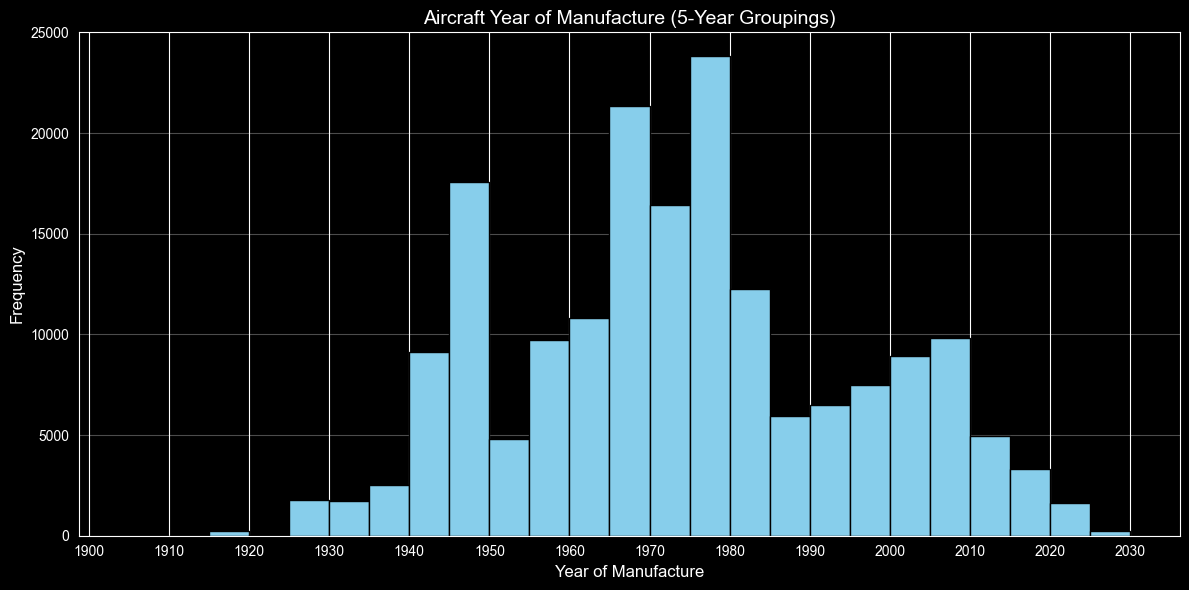

In [88]:
import matplotlib.pyplot as plt
bin_size = 5 # controls the width of the bars
tick_interval = 10   # controls how often x-axis labels appear

min_year = int(dereg_df['YEAR-MFR'].min())
max_year = int(dereg_df['YEAR-MFR'].max())

bins = np.arange(
    (min_year // bin_size) * bin_size,
    ((max_year // bin_size) + 2) * bin_size,
    bin_size
)

plt.figure(figsize=(12, 6))
dereg_df['YEAR-MFR'].hist(bins=bins, edgecolor='black', color='skyblue')

plt.title(f'Aircraft Year of Manufacture ({bin_size}-Year Groupings)', fontsize=14)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Fewer x-axis labels
tick_range = np.arange(
    (min_year // tick_interval) * tick_interval,
    max_year + tick_interval,
    tick_interval
)

print(tick_range)
plt.xticks(tick_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
empty_certs = dereg_df[dereg_df['CERTIFICATION'].str.strip() == '']

# Optional: Also include actual NaN/None values
empty_or_null = dereg_df[dereg_df['CERTIFICATION'].str.strip().isnull() | (dereg_df['CERTIFICATION'].str.strip() == '')]

empty_or_null

,N-NUMBER,SERIAL-NUMBER,MFR-MDL-CODE,STATUS-CODE,NAME,STREET-MAIL,STREET2-MAIL,CITY-MAIL,STATE-ABBREV-MAIL,ZIP-CODE-MAIL,ENG-MFR-MDL,YEAR-MFR,CERTIFICATION,REGION,COUNTY-MAIL,COUNTRY-MAIL,AIR-WORTH-DATE,CANCEL-DATE,MODE-S-CODE,INDICATOR-GROUP,EXP-COUNTRY,LAST-ACT-DATE,CERT-ISSUE-DATE,STREET-PHYSICAL,STREET2-PHYSICAL,CITY-PHYSICAL,STATE-ABBREV-PHYSICAL,ZIP-CODE-PHYSICAL,COUNTY-PHYSICAL,COUNTRY-PHYSICAL,OTHER-NAMES(1),OTHER-NAMES(2),OTHER-NAMES(3),OTHER-NAMES(4),OTHER-NAMES(5),KIT MFR,KIT MODEL,MODE S CODE HEX
19,N10005,43-48266,3021462,Triennial mailed - not returned,LEE COUNTY MOSQUITO CONTROL DISTRICT,PO BOX 60005,NaN,FORT MYERS,FL,339066005,NaN,1943,,NaN,071,US,NaT,2011-09-16,50003452,5,NaN,2007-08-21,1998-08-06,15191 HOMESTEAD RD,NaN,FORT MYERS,FL,33906,071,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0072A
21,N10007,8,05620FI,Valid Registration,COLUMBIA AIR LINERS,36TH ST & 48TH AVE,NaN,LONG ISLAND,NY,10001,NaN,1928,,1,061,US,NaT,1930-01-02,50003454,3,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0072C
23,N10008,15074750,2071826,Valid Registration,MIDALTA AVIATION,2318 SMITH CT,NaN,LONGMONT,CO,80501,NaN,1973,,S,013,US,NaT,1976-11-09,50003455,3,CANADA,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0072D
25,N10008,212,6770102,Valid Registration,MILLER MILBURN & KASSEL ROBERT O,1002 N BEND,NaN,CAPE GIRARDEAU,MO,63701,NaN,1929,,3,031,US,NaT,1930-11-13,50003455,2,NaN,NaT,1930-08-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A0072D
32,N1000D,7608,2073110,Revoked,DOUBLE M INC,109 CAPITAL AVE,NaN,FRANKFORT,KY,40601,35007,1950,,NaN,073,US,NaT,2009-06-25,50003420,3,NaN,1977-01-14,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A00710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381768,N9MD,47696,3022051,Valid Registration,WELLS FARGO BANK NATL ASSOC TRUSTEE,475 SANSOME STREET,NaN,SAN FRANCISCO,CA,94114,NaN,1977,,4,075,NaN,NaT,1978-10-28,53065621,4,FINLAND,NaT,1977-06-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6B91
381794,N9PN,222,5780407,Valid Registration,JOSEPH T BARTA ASSOC INC,HANGAR D WESTCHESTER COUNTY,AIRPORT,WHITE PLAINS,NY,10604,NaN,1972,,1,119,NaN,NaT,1976-09-22,53065714,4,FINLAND,NaT,1975-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6BCC
381799,N9PS,PSS1CRM,7220224,Sale Reported - Pending Cancellation,SALE REPORTED,RT 2 BOX 29,NaN,CORYDON,IA,50060,NaN,1972,,NaN,185,US,NaT,2012-12-11,53065720,1,NaN,2006-06-27,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AC6BD0
381821,N9RR,2169,1130790,Expired - Pending Cancellation,LAWRENCE FLOYD B,481 CALLE ARROYO,NaN,THOUSAND OAKS,CA,91360,NaN,1976,,NaN,111,US,NaT,2013-09-17,53066001,1,NaN,2007-03-12,1983-06-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LAWRENCE RUTH E,NaN,NaN,NaN,NaN,NaN,NaN,AC6C01


## Cleaning `CERTIFICATION` column
This is the same logic as for `MASTER.csv`

In [90]:
dereg_df['CERTIFICATION'].value_counts()

CERTIFICATION
1N            43483
              31463
1             28921
42            16533
1T            14428
              ...  
345               1
1UB               1
31402             1
41245             1
1AG               1
Name: count, Length: 265, dtype: int64

In [91]:
dereg_df['CERTIFICATION'] = dereg_df['CERTIFICATION'].replace(r'^\s*$', np.nan, regex=True)

In [92]:
def decode_certification(cert_code):
    # Handle missing or empty values
    if pd.isna(cert_code) or not str(cert_code).strip():
        return pd.Series({'Airworthiness_Classification': np.nan, 'Approved_Operations': np.nan})

    # Ensure it's a string (pandas sometimes reads '42' as an integer)
    cert_code = str(cert_code).strip()

    # Position 238: Airworthiness Classification (1st character)
    airworthiness_class = cert_code[0]

    # Positions 239+: Approved Operations (remaining characters)
    ops_string = cert_code[1:]

    # --- Data Dictionary Mappings ---
    class_map = {
        '1': 'Standard', '2': 'Limited', '3': 'Restricted',
        '4': 'Experimental', '5': 'Provisional', '6': 'Multiple',
        '7': 'Primary', '8': 'Special Flight Permit', '9': 'Light Sport'
    }

    standard_map = {'N': 'Normal', 'U': 'Utility', 'A': 'Acrobatic', 'T': 'Transport', 'G': 'Glider', 'B': 'Balloon', 'C': 'Commuter', 'O': 'Other'}
    restricted_map = {'0': 'Other', '1': 'Agriculture and Pest Control', '2': 'Aerial Surveying', '3': 'Aerial Advertising', '4': 'Forest', '5': 'Patrolling', '6': 'Weather Control', '7': 'Carriage of Cargo'}
    experimental_map = {
        '0': 'To show compliance with FAR', '1': 'Research and Development', '2': 'Amateur Built', '3': 'Exhibition', '4': 'Racing', '5': 'Crew Training',
        '6': 'Market Survey', '7': 'Operating Kit Built Aircraft', '8A': 'Reg. Prior to 01/31/08', '8B': 'Operating Light-Sport Kit-Built',
        '8C': 'Operating Light-Sport Previously issued cert under 21.190', '9A': 'Unmanned Aircraft - Research and Development',
        '9B': 'Unmanned Aircraft - Market Survey', '9C': 'Unmanned Aircraft - Crew Training', '9D': 'Unmanned Aircraft - Exhibition', '9E': 'Unmanned Aircraft - Compliance With CFR'
    }
    provisional_map = {'1': 'Class I', '2': 'Class II'}
    multiple_cert_map = {'1': 'Standard', '2': 'Limited', '3': 'Restricted'}
    special_map = {'1': 'Ferry flight for repairs, alterations, maintenance or storage', '2': 'Evacuate from area of impending danger', '3': 'Operation in excess of maximum certificated', '4': 'Delivery or export', '5': 'Production flight testing', '6': 'Customer Demo'}
    light_sport_map = {'A': 'Airplane', 'G': 'Glider', 'L': 'Lighter than Air', 'P': 'Power-Parachute', 'W': 'Weight-Shift-Control'}

    # Determine primary classification
    primary_class_name = class_map.get(airworthiness_class, f'Unknown({airworthiness_class})')
    ops_list = []

    # Parse operations based on primary classification rules
    if ops_string:
        if airworthiness_class == '1':
            ops_list = [standard_map.get(char, f'Unknown({char})') for char in ops_string]

        elif airworthiness_class == '3':
            ops_list = [restricted_map.get(char, f'Unknown({char})') for char in ops_string]

        elif airworthiness_class == '4':
            # Experimental has 2-character codes (like 8A, 9C), so we need to parse greedily
            i = 0
            while i < len(ops_string):
                if i + 1 < len(ops_string) and ops_string[i:i+2] in experimental_map:
                    ops_list.append(experimental_map[ops_string[i:i+2]])
                    i += 2
                else:
                    ops_list.append(experimental_map.get(ops_string[i], f'Unknown({ops_string[i]})'))
                    i += 1

        elif airworthiness_class == '5':
            ops_list = [provisional_map.get(char, f'Unknown({char})') for char in ops_string]

        elif airworthiness_class == '6':
            # Multiple has cert codes in first two positions, restricted operations in the rest
            for i, char in enumerate(ops_string):
                if i < 2:
                    ops_list.append(f"Cert: {multiple_cert_map.get(char, f'Unknown({char})')}")
                else:
                    ops_list.append(restricted_map.get(char, f'Unknown({char})'))

        elif airworthiness_class == '8':
            ops_list = [special_map.get(char, f'Unknown({char})') for char in ops_string]

        elif airworthiness_class == '9':
            ops_list = [light_sport_map.get(char, f'Unknown({char})') for char in ops_string]

        # Note: Classes 2 (Limited) and 7 (Primary) have blank operations records

    return pd.Series({
        'Airworthiness_Classification': primary_class_name,
        'Approved_Operations': ', '.join(ops_list) if ops_list else np.nan
    })

# Apply the function to create two new, clean columns
dereg_df[['Airworthiness_Classification', 'Approved_Operations']] = dereg_df['CERTIFICATION'].apply(decode_certification)

# View the result
print(dereg_df[['CERTIFICATION', 'Airworthiness_Classification', 'Approved_Operations']].head(10))

   CERTIFICATION Airworthiness_Classification           Approved_Operations
7     31                           Restricted  Agriculture and Pest Control
8     31                           Restricted  Agriculture and Pest Control
14    31                           Restricted  Agriculture and Pest Control
16    1                              Standard                           NaN
19           NaN                          NaN                           NaN
21           NaN                          NaN                           NaN
23           NaN                          NaN                           NaN
25           NaN                          NaN                           NaN
26    42                         Experimental                 Amateur Built
30    1                              Standard                           NaN


In [93]:
dereg_df['CERTIFICATION'] = dereg_df['CERTIFICATION'].str.strip()

## Cleaning `Region` column

In [94]:
dereg_df['REGION'].value_counts(dropna=False)

REGION
NaN    156159
1        4947
C        4465
2        3578
4        3481
7        2568
3        2456
S        1981
E         913
5         424
Name: count, dtype: int64

In [95]:
region_map = {
    '1': 'Eastern',
    '2': 'Southwestern',
    '3': 'Central',
    '4': 'Western-Pacific',
    '5': 'Alaskan',
    '7': 'Southern',
    '8': 'European',
    'C': 'Great Lakes',
    'E': 'New England',
    'S': 'Northwest Mountain'
}

dereg_df['REGION'] = dereg_df['REGION'].map(region_map)

# Verify the update
print(dereg_df['REGION'].value_counts(dropna=False))

REGION
NaN                   156159
Eastern                 4947
Great Lakes             4465
Southwestern            3578
Western-Pacific         3481
Southern                2568
Central                 2456
Northwest Mountain      1981
New England              913
Alaskan                  424
Name: count, dtype: int64


## Cleaning "TYPE REGISTRANT" column


In [96]:
dereg_df['INDICATOR-GROUP'].value_counts(dropna=False)

INDICATOR-GROUP
1      90945
3      68571
4       8901
7       4404
2       3329
5       2147
8       1824
NaN      846
9          5
Name: count, dtype: int64

In [97]:
type_registrant_map = {
    '1': 'Individual',
    '2': 'Partnership',
    '3': 'Corporation',
    '4': 'Co-Owned',
    '5': 'Government',
    '7': 'LLC',
    '8': 'Non Citizen Corporation',
    '9': 'Non Citizen Co-Owned'
}

dereg_df['INDICATOR-GROUP'] = dereg_df['INDICATOR-GROUP'].map(type_registrant_map)

In [98]:
dereg_df['INDICATOR-GROUP'].value_counts(dropna=False)

INDICATOR-GROUP
Individual                 90945
Corporation                68571
Co-Owned                    8901
LLC                         4404
Partnership                 3329
Government                  2147
Non Citizen Corporation     1824
NaN                          846
Non Citizen Co-Owned           5
Name: count, dtype: int64

In [99]:
dereg_df['REGION'].value_counts(dropna=False)

REGION
NaN                   156159
Eastern                 4947
Great Lakes             4465
Southwestern            3578
Western-Pacific         3481
Southern                2568
Central                 2456
Northwest Mountain      1981
New England              913
Alaskan                  424
Name: count, dtype: int64

## Final Cleaning

In [100]:
dereg_df.columns = (dereg_df.columns
                     .str.replace(' ', '_', regex=False)
                     .str.replace('-', '_', regex=False)
                     .str.replace('(', '', regex=False)
                     .str.replace(')', '', regex=False)
                     .str.lower())

In [101]:
cols = list(dereg_df.columns)

# Columns to move
cols_to_move = ['airworthiness_classification', 'approved_operations']

# Remove them from current position
for col in cols_to_move:
    cols.remove(col)

# Insert right after column index 12
insert_position = 13  # after index 12
for col in reversed(cols_to_move):
    cols.insert(insert_position, col)

# Reorder dataframe
dereg_df = dereg_df[cols]

In [102]:
dereg_df.info()

<class 'pandas.DataFrame'>
Index: 180972 entries, 7 to 381931
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   n_number                      180972 non-null  str           
 1   serial_number                 180972 non-null  str           
 2   mfr_mdl_code                  180972 non-null  str           
 3   status_code                   180972 non-null  str           
 4   name                          179659 non-null  str           
 5   street_mail                   177925 non-null  str           
 6   street2_mail                  8585 non-null    str           
 7   city_mail                     179214 non-null  str           
 8   state_abbrev_mail             175787 non-null  str           
 9   zip_code_mail                 178165 non-null  str           
 10  eng_mfr_mdl                   152270 non-null  str           
 11  year_mfr                     

In [103]:
dereg_df = dereg_df.rename(columns={
    'indicator_group': 'owner_type',
})

In [104]:
dereg_df.to_csv('./clean_data/DEREG.csv', index=False, na_rep='')